y_pred: [0 1 1 0 0 0 1 1 0 1 1 0 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 0 1 1 0 1 0 0 1 1 1
 1 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 1 0
 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1
 1 1 1 1 0 0 0 1 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 0 1 0 0 0 0 0 1 0 0 0 1 0 1
 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1 0 0 0 1
 1 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 0 0 0 1 1 0 0 1 0 1 0
 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0 1 0 0 1 1 1 0 1 1 0 0 0 1 0 0 0 0 0 1 0 0 0
 1 0 1 0 0 1 1 0 0 1 0 0 1 1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 1 1 1 1 0 1 0 0 1
 1 1 0 1]
precision: 0.8958333333333334
recall: 0.8486842105263158
precision_recall: (array([0.50666667, 0.89583333, 1.        ]), array([1.        , 0.84868421, 0.        ]), array([0, 1]))
y_prob: [0.01522645 0.98832299 0.79322573 0.45994683 0.08764338 0.35172641
 0.93184249 0.89670371 0.17466738 0.8629698  0.95729523 0.02865428
 0.516692   0.93215311 0.99556511 0.94533679 0.91704896 0.5

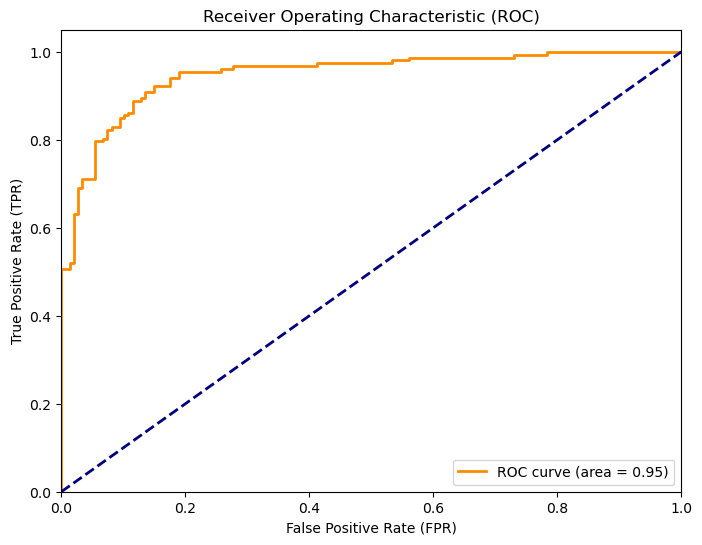

Thresholds: [       inf 0.99959599 0.8921583  0.88974224 0.88733044 0.884806
 0.80774532 0.80591105 0.773809   0.7612924  0.75000405 0.72508023
 0.6291247  0.62157328 0.58698522 0.58329935 0.5756632  0.56479789
 0.55686123 0.52940823 0.51165522 0.51028614 0.49804779 0.48285411
 0.45994683 0.45096752 0.42302882 0.41932289 0.39164259 0.38035825
 0.37662177 0.36237446 0.35172641 0.33872687 0.31798778 0.30352186
 0.29463433 0.24384763 0.24354022 0.22379481 0.22088327 0.13656003
 0.13645596 0.09788453 0.0977073  0.09019782 0.0900705  0.05210353
 0.05197777 0.04064972 0.04059129 0.00339434]
FPR: [0.         0.         0.         0.01351351 0.01351351 0.02027027
 0.02027027 0.02702703 0.02702703 0.03378378 0.03378378 0.05405405
 0.05405405 0.06756757 0.06756757 0.07432432 0.07432432 0.08108108
 0.08108108 0.09459459 0.09459459 0.10135135 0.10135135 0.10810811
 0.10810811 0.11486486 0.11486486 0.12837838 0.12837838 0.13513514
 0.13513514 0.14864865 0.14864865 0.17567568 0.17567568 0.18918919
 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

# Generate a synthetic dataset
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2,
                           n_redundant=0, random_state=42)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42)

# Train a logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"y_pred: {y_pred}")

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision_recall = precision_recall_curve(y_test, y_pred)

print(f"precision: {precision}")
print(f"recall: {recall}")
print(f"precision_recall: {precision_recall}")


# Predict probabilities for the test set
y_prob = model.predict_proba(X_test)[:, 1]
print(f"y_prob: {y_prob}")

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
# fpr, tpr, thresholds = roc_curve(y_test, y_pred)
print(f"fpr: {fpr}")
print(f"tpr: {tpr}")
print(f"thresholds: {thresholds}")

# Calculate the AUC (Area Under the Curve)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Print FPR and TPR values with corresponding thresholds
print("Thresholds:", thresholds)
print("FPR:", fpr)
print("TPR:", tpr)